<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab0/L0_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 0.2 Purdue Cisco VPN and Tailscale Device Network


## Learning Goals

Students will be able to:

1. Explain the different purposes of Purdue Cisco VPN and Tailscale.
2. Use Purdue Cisco VPN to access the Purdue network from an off-campus or online environment.
3. Install and authenticate Tailscale on a laptop and Raspberry Pi.
4. Identify the Tailscale IP address assigned to each device.
5. Select the appropriate VPN tool based on the required network path.


## 2.1 Introduction: Two Different VPN Roles

This lab introduces **Purdue Cisco VPN** and **Tailscale**. Although both are called VPNs, they solve different network problems.

### Purdue Cisco VPN

Purdue Cisco VPN connects an off-campus or online user to the **Purdue network**. After connecting, the user's computer has a logical path into Purdue's network environment.

Its main role in this lab is:

> **Online student → Purdue network → Purdue-network device or resource**

For example, an online student may need Purdue Cisco VPN to recognize or access a device that is only reachable from within Purdue's network.

### Tailscale

Tailscale creates a private **device-to-device overlay network**. Each authenticated device receives a Tailscale IP address, usually in the `100.x.x.x` range.

Its main role in this lab is:

> **Laptop ↔ Tailscale network ↔ Raspberry Pi**

This is useful on a secured network such as PAL 3.0, where both devices may have Internet access but direct local communication between them may be restricted. Tailscale provides a private communication path without requiring the laptop and Raspberry Pi to remain connected by an Ethernet cable.

### Key Difference

| Tool | Primary purpose | Typical network path |
|---|---|---|
| Purdue Cisco VPN | Connect a remote user into the Purdue network | Online student → Purdue network |
| Tailscale | Connect authenticated devices through a private overlay network | Laptop ↔ Raspberry Pi |
| Direct Ethernet | Create a local physical link between two nearby devices | Laptop ↔ Ethernet cable ↔ Raspberry Pi |

Purdue Cisco VPN and Tailscale are therefore **complementary rather than interchangeable**. Purdue Cisco VPN provides access **into Purdue's network**, while Tailscale provides a private connection **between registered devices**.


## 2.2 Purdue Cisco VPN for Online Students

Online students may be outside the Purdue network. Purdue Cisco VPN creates a secure path from the student's current Internet connection into Purdue's network.

### Use Purdue Cisco VPN when:

- You are off campus or enrolled online.
- A Purdue resource is available only from within the Purdue network.
- You need your computer to recognize or access a device that is reachable through Purdue's internal network.

### Raspberry Pi VPN Client Installation

Install the required packages:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
sudo apt install openconnect -y
sudo apt install network-manager-openconnect-gnome -y
```

---

Connect to Purdue Cisco VPN:

```bash
sudo openconnect -u <PURDUE_USERNAME> -b webvpn2.purdue.edu
```

Enter your Purdue credentials when prompted.

To disconnect the VPN client:

```bash
sudo kill -9 $(pgrep openconnect | awk '{print $1}')
```

> Purdue Cisco VPN does not automatically create a private device-to-device network between the laptop and Raspberry Pi. It provides a route into Purdue's network. Direct communication may still depend on the Purdue network configuration, local firewall settings, and the destination device's accessibility.


## 2.3 When to Use Purdue Cisco VPN and Tailscale Together

The two VPNs may be used in the same overall workflow, but they operate at different layers.

### Scenario A — Online Student Accessing the Purdue Environment

The student first uses Purdue Cisco VPN:

```text
Online laptop
    ↓
Purdue Cisco VPN
    ↓
Purdue network
```

This makes Purdue-network resources visible to the remote student.

### Scenario B — Laptop Communicating with Raspberry Pi on a Secured Network

The laptop and Raspberry Pi use Tailscale:

```text
Laptop
    ↓
Internet / secured network
    ↓
Tailscale private overlay
    ↓
Raspberry Pi
```

This creates a private route between the two registered devices even when PAL 3.0 does not allow direct local ping.

### Combined Interpretation

Purdue Cisco VPN answers:

> “How can an online student enter the Purdue network?”

Tailscale answers:

> “How can the laptop and Raspberry Pi communicate privately without a direct Ethernet cable?”

For this lab's final communication test, the direct Ethernet cable will be disconnected and the laptop and Raspberry Pi will ping each other using their Tailscale IP addresses.


## 2.4 Before Starting

Complete the following checks before installing Tailscale:

1. Connect the laptop to PAL 3.0 or another network with Internet access.
2. Connect the Raspberry Pi to PAL 3.0 or another network with Internet access.
3. Keep the Ethernet cable connected temporarily if it is still needed to access the Raspberry Pi.
4. Confirm Internet access from the Raspberry Pi.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
ping -c 4 tailscale.com
```

---

A successful response confirms that the Raspberry Pi can reach the Internet. Tailscale cannot establish a remote connection when the device has no Internet access.


## 2.5 Install Tailscale on Your Laptop

1. Open the Tailscale download page:

   https://tailscale.com/download

2. Download and install the version for your operating system.
3. Start Tailscale.
4. Sign in using your Gmail account.
5. Keep Tailscale running in the background.

Use the **same Tailscale account** for the laptop and Raspberry Pi so that both devices are added to the same tailnet.

> **Account reminder:** Use the Gmail account assigned for your lab group or deployment. Do not add the Raspberry Pi to an unrelated personal tailnet.


## 2.6 Install Tailscale on Raspberry Pi

Access the Raspberry Pi terminal using the direct Ethernet connection, SSH, or VNC. Install Tailscale with the following command.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
curl -fsSL https://tailscale.com/install.sh | sh
```

---

After installation, start the Tailscale authentication process.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
sudo tailscale up
```

---

The terminal will display an authentication URL.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_summer/Lab0_fig_tailscale_terminal.png?raw=true" width="40%">

*Figure 1. Authentication URL shown after running `sudo tailscale up`.*


## 2.7 Authenticate the Raspberry Pi

1. Open the authentication URL displayed in the Raspberry Pi terminal.
2. Sign in using the **same Gmail account** used on the laptop.
3. Confirm that the device name shown on the page is your Raspberry Pi.
4. Click **Connect**.
5. Wait until the browser reports that login was successful.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_summer/Lab0_fig_tailscale_authentication.png?raw=true" width="40%">

*Figure 2. Connecting the Raspberry Pi to the Tailscale account.*

After authentication, return to the Raspberry Pi terminal. Check the connection status:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
tailscale status
```

---

The laptop and Raspberry Pi should both appear in the device list.


## 2.8 Find the Tailscale IP Addresses

Each Tailscale device receives a private IP address, typically in the `100.x.x.x` range. This address is different from the local PAL 3.0 Wi-Fi address.

### Raspberry Pi

Run:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
tailscale ip -4
```

---

Record the Raspberry Pi Tailscale IP address.

### Laptop

Open the Tailscale application or Tailscale administration page and locate the laptop's Tailscale IP address.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S26_summer/Lab0_fig_tailscale_machines.png?raw=true" width="40%">

*Figure 3. Tailscale device list and assigned VPN addresses.*

Example:

| Device | Example Tailscale IP |
|---|---:|
| Raspberry Pi | `100.92.117.35` |
| Laptop | `100.75.97.7` |

Your addresses will be different from these examples.


## 2.9 Disconnect the Direct Ethernet Cable

Before testing the Tailscale connection:

1. Confirm that both the laptop and Raspberry Pi are connected to PAL 3.0 or another Internet-connected network.
2. Confirm that both devices appear as **Connected** in Tailscale.
3. Disconnect the Ethernet cable between the laptop and Raspberry Pi.
4. Wait approximately 10–20 seconds for the network routes to update.

This step is important. The following test must verify communication through the Tailscale network rather than through the previous direct Ethernet connection.

You may confirm the Raspberry Pi's active interfaces using:

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
ip addr
```

---

The `tailscale0` interface should be present. The direct Ethernet interface should no longer provide the laptop-to-Raspberry Pi connection.


## 2.10 Test Bidirectional Communication Through Tailscale

### Test 1: Laptop to Raspberry Pi

On the laptop, open Command Prompt or a terminal and ping the **Raspberry Pi's Tailscale IP address**.

---

**Windows Laptop - Command Prompt**

```text
ping <RASPBERRY_PI_TAILSCALE_IP>
```

Example:

```text
ping 100.92.117.35
```

---

### Test 2: Raspberry Pi to Laptop

On the Raspberry Pi, ping the **laptop's Tailscale IP address**.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_RaspberryPi.png?raw=true" width="20"> Raspberry Pi - Terminal**

```bash
ping -c 4 <LAPTOP_TAILSCALE_IP>
```

Example:

```bash
ping -c 4 100.75.97.7
```

---

A successful response in both directions confirms that the devices can communicate through the Tailscale VPN.

> The local PAL 3.0 addresses may still be unable to ping each other because of network isolation or firewall rules. That does not indicate a Tailscale failure. For this task, use the `100.x.x.x` Tailscale addresses.


### Task 2.1 — Tailscale Bidirectional Ping Test

Complete the following steps:

1. Disconnect the direct Ethernet cable between the laptop and Raspberry Pi.
2. Confirm that both devices still have Internet access.
3. From the laptop, ping the Raspberry Pi using its Tailscale IP address.
4. From the Raspberry Pi, ping the laptop using its Tailscale IP address.
5. Capture screenshots showing successful ping responses in both directions.
6. Attach the screenshots below.

**Laptop Tailscale IP:** `100.126.66.85`

**Raspberry Pi Tailscale IP:** `100.107.113.48`

---
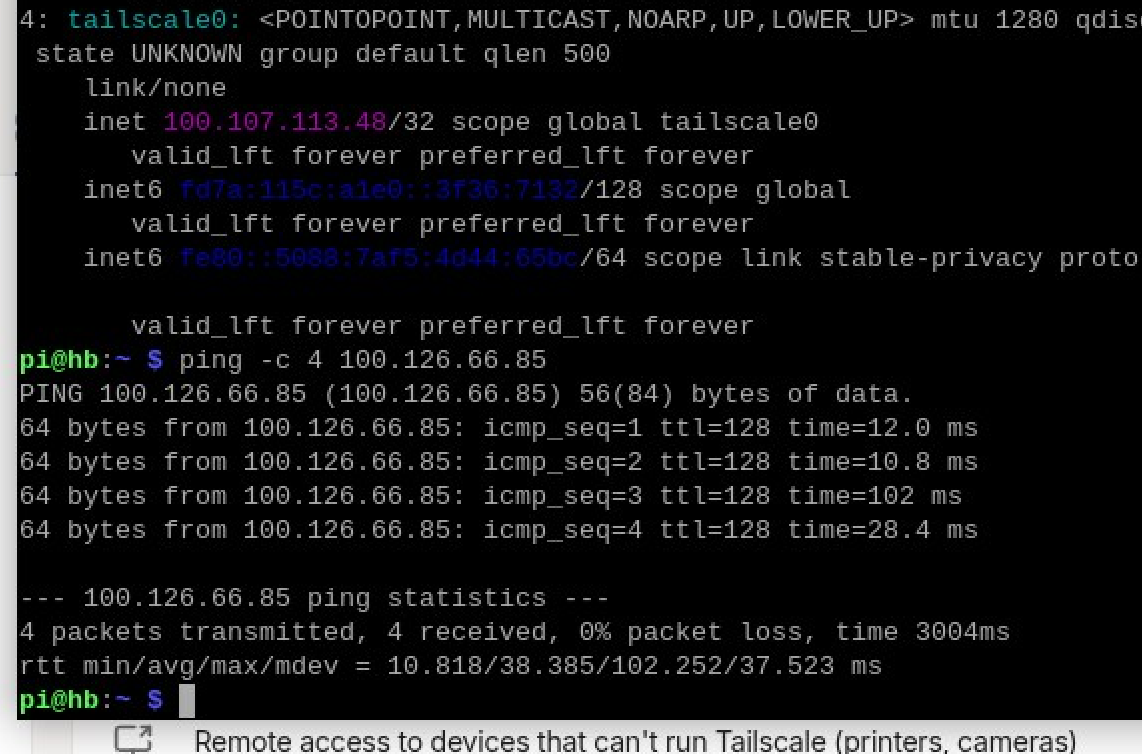

---

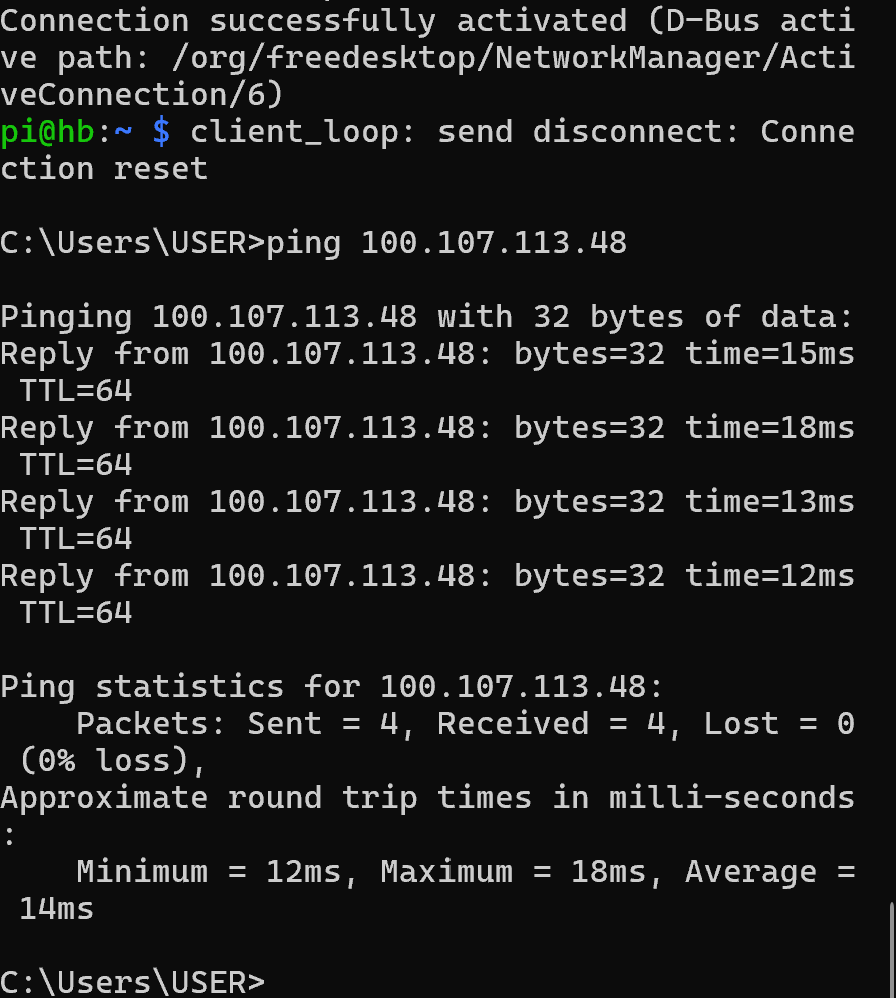

---


## 2.11 Remote Access Through Tailscale

After the ping test succeeds, the Raspberry Pi can be accessed using its Tailscale IP address.

For example, from the laptop:

```text
ssh pi@<RASPBERRY_PI_TAILSCALE_IP>
```

Example:

```text
ssh pi@100.92.117.35
```

You may also enter the Raspberry Pi's Tailscale IP address in a remote desktop application when the corresponding remote desktop service is enabled.

Because Tailscale uses the Internet to connect the devices, the laptop and Raspberry Pi do not need to remain on the same local network. For example:

- The Raspberry Pi can remain connected to PAL 3.0 in the laboratory.
- The laptop can connect from another Internet-connected network.
- Tailscale can still provide a private path between them.

Both devices must be powered on, connected to the Internet, signed in to the same tailnet, and permitted by the tailnet's access policy.


## 2.12 Troubleshooting

### The device does not appear in `tailscale status`

Run:

```bash
sudo tailscale up
```

Then complete browser authentication again using the correct Gmail account.

### Ping fails after disconnecting Ethernet

Check the following:

- Both devices have Internet access.
- Tailscale is running on both devices.
- Both devices are signed in to the same tailnet.
- You are using the Tailscale `100.x.x.x` addresses, not the PAL 3.0 local addresses.
- The device status is **Connected**, not offline.
- The laptop firewall permits Tailscale traffic.

### Check the Raspberry Pi connection

```bash
tailscale status
tailscale ip -4
ip addr show tailscale0
```

### Restart Tailscale on Raspberry Pi

```bash
sudo systemctl restart tailscaled
sudo tailscale up
```

### Disconnect the Raspberry Pi from the current tailnet

Use this only when you need to authenticate with a different account:

```bash
sudo tailscale logout
sudo tailscale up
```


## Deliverable 2

Respond to the following prompts and include the Task 2.1 screenshots.


In [ ]:
#@title 1. Summarize Lab 0. What did you learn from Lab 0.1 and Lab 0.2?

Text = '' #@param {type:"string"}

print(Text)


In [ ]:
#@title 2. Compare SSH and VNC. What are the advantages and disadvantages of each remote access method?

Text = '' #@param {type:"string"}

print(Text)


In [ ]:
#@title 3. Explain the difference between Purdue Cisco VPN and Tailscale. When would you use each one?

Text = '' #@param {type:"string"}

print(Text)


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)
